# Importing Libraries 

In [70]:
import os
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

import tensorflow as tf
import keras 

from tensorflow.keras.layers import TextVectorization, Embedding, SimpleRNN, Dense, LSTM, GRU, Bidirectional
from tensorflow.keras.models import Sequential
from datasets import load_dataset
from tensorflow.keras import Input

from sklearn.metrics import accuracy_score

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Loading datasets

In [2]:
dataset = load_dataset("glue", "sst2")

train_sentences = list(dataset['train']['sentence'])
train_labels = list(dataset['train']['label'])

val_sentences = list(dataset['validation']['sentence'])
val_labels = list(dataset['validation']['label'])

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

# Data Preprocessing 

In [3]:
VOCAB_SIZE = 10000
MAX_LEN = 30

vectorize_layer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
) 

I0000 00:00:1776513892.126482      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
vectorize_layer.adapt(train_sentences)

In [5]:
def create_dataset(sentences, labels, batch_size=32):
    # Map sentences and labels into a TF Dataset
    ds = tf.data.Dataset.from_tensor_slices((sentences, labels))
    # Batch and prefetch for performance
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_sentences, train_labels)
val_ds = create_dataset(val_sentences, val_labels)

# Simple RNN Model 

In [6]:
model_rnn = Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

In [7]:
model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_rnn = model_rnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 98s 44ms/step - accuracy: 0.7726 - loss: 0.4496 - val_accuracy: 0.7982 - val_loss: 0.4988
Epoch 2/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 92s 44ms/step - accuracy: 0.9213 - loss: 0.2001 - val_accuracy: 0.7787 - val_loss: 0.6145
Epoch 3/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 93s 44ms/step - accuracy: 0.9464 - loss: 0.1395 - val_accuracy: 0.7695 - val_loss: 0.7196
Epoch 4/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 93s 44ms/step - accuracy: 0.9581 - loss: 0.1112 - val_accuracy: 0.7718 - val_loss: 0.7565
Epoch 5/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 97s 46ms/step - accuracy: 0.9650 - loss: 0.0880 - val_accuracy: 0.7580 - val_loss: 0.8451


# LSTM Model 

In [51]:
model_lstm = Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=False),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

In [52]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [53]:
model_lstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history_lstm = model_lstm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.5980 - loss: 0.6465 - val_accuracy: 0.6674 - val_loss: 0.6493
Epoch 2/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7572 - loss: 0.5307 - val_accuracy: 0.7970 - val_loss: 0.4656
Epoch 3/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8927 - loss: 0.2645 - val_accuracy: 0.8222 - val_loss: 0.4156
Epoch 4/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9278 - loss: 0.1796 - val_accuracy: 0.8177 - val_loss: 0.4785
Epoch 5/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9442 - loss: 0.1360 - val_accuracy: 0.8096 - val_loss: 0.5835


# GRU Model

In [55]:
model_gru = Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=False),
    GRU(64),
    Dense(1, activation='sigmoid')
])

In [56]:
model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [57]:
model_gru.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
history_gru = model_gru.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.6036 - loss: 0.6437 - val_accuracy: 0.8314 - val_loss: 0.4304
Epoch 2/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8951 - loss: 0.2586 - val_accuracy: 0.8417 - val_loss: 0.4165
Epoch 3/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9295 - loss: 0.1759 - val_accuracy: 0.8326 - val_loss: 0.4662
Epoch 4/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9464 - loss: 0.1317 - val_accuracy: 0.8394 - val_loss: 0.5410
Epoch 5/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9557 - loss: 0.1045 - val_accuracy: 0.8349 - val_loss: 0.6023


# Plotting Accuracy and Loss Graphs

In [59]:
def plot_training_history(history_dict, model_name):
    # Extract the metrics
    acc = history_dict.history['accuracy']
    val_acc = history_dict.history['val_accuracy']
    loss = history_dict.history['loss']
    val_loss = history_dict.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Create a 1x2 grid of plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} Training History', fontsize=16)

    # Plot Accuracy
    ax1.plot(epochs, acc, 'bo-', label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot Loss
    ax2.plot(epochs, loss, 'bo-', label='Training Loss')
    ax2.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.show()

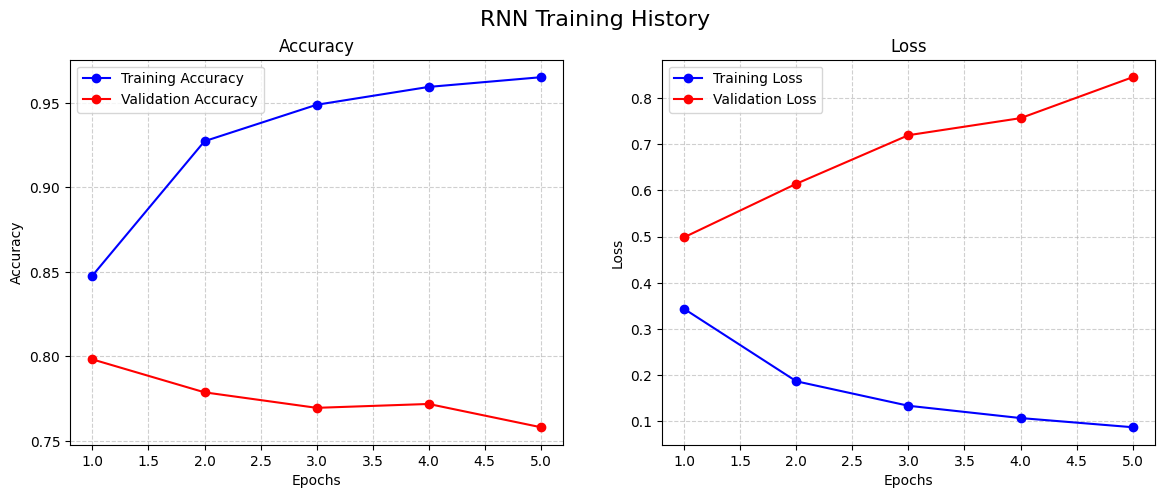

In [60]:
plot_training_history(history_rnn, "RNN")

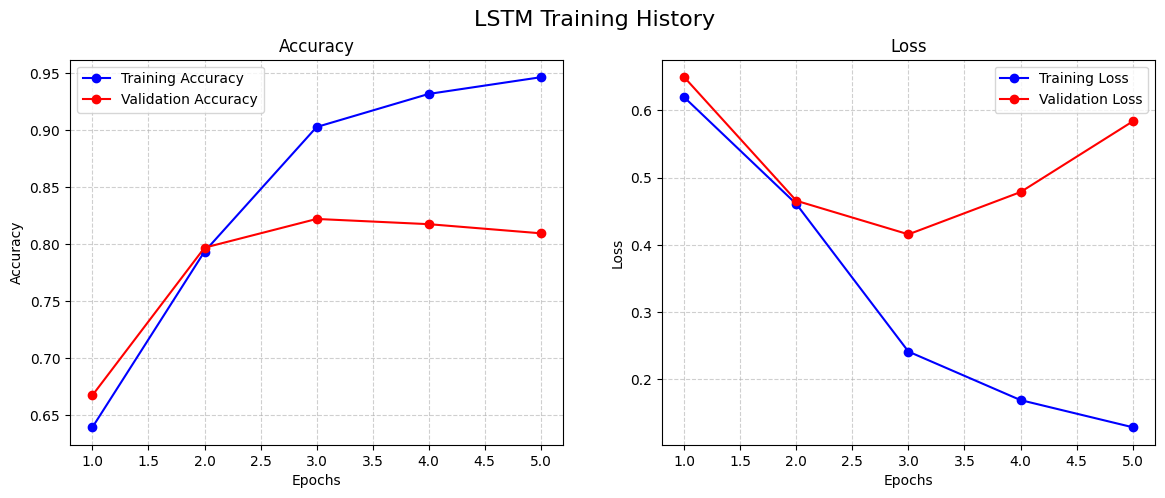

In [61]:
plot_training_history(history_lstm, "LSTM")

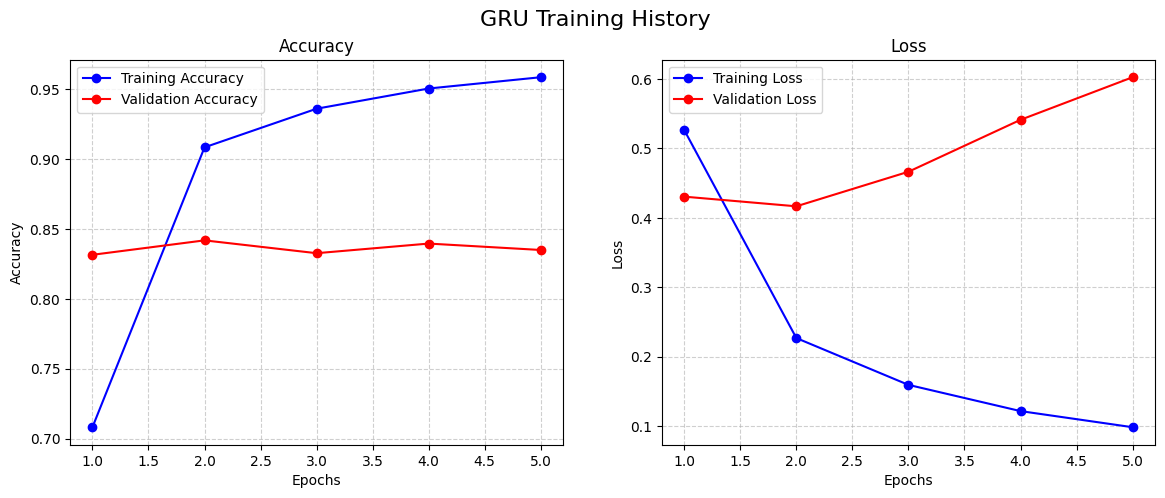

In [62]:
plot_training_history(history_gru, "GRU")


# Testing Simple RNN Model 

In [63]:
test_sentences = [
    "This movie was absolutely amazing, I loved the brilliant acting.",
    "The visual effects were stunning, but the plot was extremely slow and the ending felt like a complete letdown overall.",
    "While the soundtrack was beautiful and the cinematography captured the scenery perfectly, the terrible dialogue, confusing storyline, and absolute lack of character development completely ruined what could have been a cinematic masterpiece."
]

test_input = tf.constant(test_sentences, dtype=tf.string)

In [64]:
predictions_rnn = model_rnn.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [65]:
predictions_lstm = model_lstm.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


In [66]:
predictions_gru = model_gru.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


In [67]:
for i, review in enumerate(test_sentences):
    score = predictions_rnn[i][0]
    sentiment = "Positive" if score >= 0.5 else "Negative"
    
    print(f"Review: '{review}'")
    print(f"Confidence Score: {score:.4f} -> {sentiment}\n")

Review: 'This movie was absolutely amazing, I loved the brilliant acting.'
Confidence Score: 0.9824 -> Positive

Review: 'The visual effects were stunning, but the plot was extremely slow and the ending felt like a complete letdown overall.'
Confidence Score: 0.0003 -> Negative

Review: 'While the soundtrack was beautiful and the cinematography captured the scenery perfectly, the terrible dialogue, confusing storyline, and absolute lack of character development completely ruined what could have been a cinematic masterpiece.'
Confidence Score: 0.0021 -> Negative



In [68]:
for i, review in enumerate(test_sentences):
    score = predictions_lstm[i][0]
    sentiment = "Positive" if score >= 0.5 else "Negative"
    
    print(f"Review: '{review}'")
    print(f"Confidence Score: {score:.4f} -> {sentiment}\n")

Review: 'This movie was absolutely amazing, I loved the brilliant acting.'
Confidence Score: 0.9994 -> Positive

Review: 'The visual effects were stunning, but the plot was extremely slow and the ending felt like a complete letdown overall.'
Confidence Score: 0.0049 -> Negative

Review: 'While the soundtrack was beautiful and the cinematography captured the scenery perfectly, the terrible dialogue, confusing storyline, and absolute lack of character development completely ruined what could have been a cinematic masterpiece.'
Confidence Score: 0.9702 -> Positive



In [69]:
for i, review in enumerate(test_sentences):
    score = predictions_gru[i][0]
    sentiment = "Positive" if score >= 0.5 else "Negative"
    
    print(f"Review: '{review}'")
    print(f"Confidence Score: {score:.4f} -> {sentiment}\n")

Review: 'This movie was absolutely amazing, I loved the brilliant acting.'
Confidence Score: 0.9998 -> Positive

Review: 'The visual effects were stunning, but the plot was extremely slow and the ending felt like a complete letdown overall.'
Confidence Score: 0.0010 -> Negative

Review: 'While the soundtrack was beautiful and the cinematography captured the scenery perfectly, the terrible dialogue, confusing storyline, and absolute lack of character development completely ruined what could have been a cinematic masterpiece.'
Confidence Score: 0.0035 -> Negative



# Bidirectional Deep GRU 

In [71]:
model = Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=False),
    Bidirectional(GRU(64, return_sequences=True)),
    Bidirectional(GRU(32)),
    Dense(1, activation='sigmoid')
])

In [72]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [73]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721,089 (2.75 MB)

 Trainable params: 721,089 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.7831 - loss: 0.4284 - val_accuracy: 0.8303 - val_loss: 0.4134
Epoch 2/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9218 - loss: 0.1952 - val_accuracy: 0.8245 - val_loss: 0.4671
Epoch 3/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9459 - loss: 0.1351 - val_accuracy: 0.8085 - val_loss: 0.5535
Epoch 4/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9592 - loss: 0.1003 - val_accuracy: 0.8028 - val_loss: 0.7225
Epoch 5/5
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9691 - loss: 0.0756 - val_accuracy: 0.7959 - val_loss: 0.7676


In [75]:
predictions = model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


In [76]:
for i, review in enumerate(test_sentences):
    score = predictions[i][0]
    sentiment = "Positive" if score >= 0.5 else "Negative"
    
    print(f"Review: '{review}'")
    print(f"Confidence Score: {score:.4f} -> {sentiment}\n")

Review: 'This movie was absolutely amazing, I loved the brilliant acting.'
Confidence Score: 0.9999 -> Positive

Review: 'The visual effects were stunning, but the plot was extremely slow and the ending felt like a complete letdown overall.'
Confidence Score: 0.0004 -> Negative

Review: 'While the soundtrack was beautiful and the cinematography captured the scenery perfectly, the terrible dialogue, confusing storyline, and absolute lack of character development completely ruined what could have been a cinematic masterpiece.'
Confidence Score: 0.9992 -> Positive



# Prediction of all models on long sentence

In [80]:
sentence_50 = [
    "Although the visuals were stunning and the acting was truly a masterpiece of emotional depth that promised an incredible journey, the actual film was a boring disaster with a nonsensical plot that ultimately turned what could have been a glorious success into an insulting and utterly miserable waste of time."
]

test_input_50 = tf.constant(sentence_50, dtype=tf.string)

models = {
    "Vanilla RNN": model_rnn,
    "LSTM": model_lstm,
    "GRU": model_gru,
    "Deep Bidirectional GRU": model
}

for name, model in models.items():
    pred = model.predict(test_input_50, verbose=0)[0][0]
    sentiment = "Positive" if pred >= 0.5 else "Negative"
    print(f"{name:22} | Score: {pred:.4f} -> {sentiment}")

Vanilla RNN            | Score: 0.0014 -> Negative
LSTM                   | Score: 0.9682 -> Positive
GRU                    | Score: 0.3586 -> Negative
Deep Bidirectional GRU | Score: 0.5904 -> Positive
